In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
data = pd.read_csv(r"D:\Ultimate Programming\Data Bases\Groceries_dataset.csv")

In [3]:
data.head(2)

,Member_number,Date,itemDescription
0,1808,21-07-2015,tropical fruit
1,2552,05-01-2015,whole milk


In [4]:
data['transactionID'] = data['Member_number'].astype(str) + "_" + data['Date']

In [5]:
data.head(2)

,Member_number,Date,itemDescription,transactionID
0,1808,21-07-2015,tropical fruit,1808_21-07-2015
1,2552,05-01-2015,whole milk,2552_05-01-2015


In [6]:
data.drop(columns=['Member_number','Date'], axis=1, inplace=True)

In [7]:
data.isnull().sum()

itemDescription    0
transactionID      0
dtype: int64

In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38765 entries, 0 to 38764
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   itemDescription  38765 non-null  object
 1   transactionID    38765 non-null  object
dtypes: object(2)
memory usage: 605.8+ KB


In [9]:
dt = data['itemDescription'].value_counts().reset_index().sort_values(by='count', ascending=False).head(10)
dt.columns = ['item', 'values']

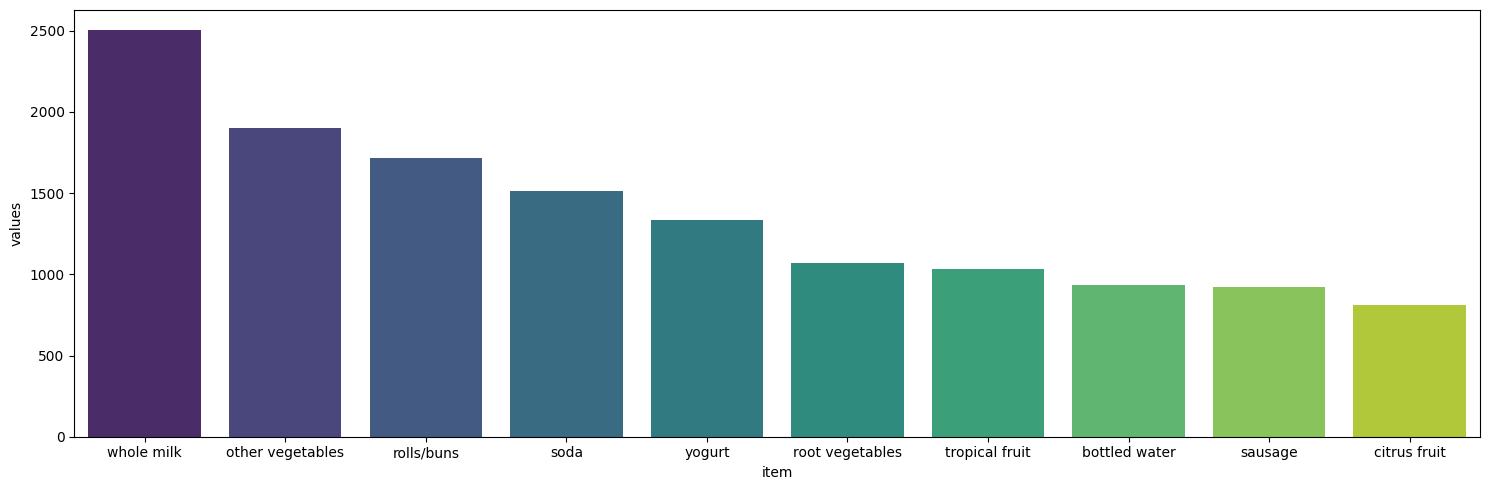

In [10]:
plt.figure(figsize=(15,5))
sns.barplot(data=dt, x='item', y='values', palette='viridis')
plt.tight_layout()
plt.show()

In [11]:
data['itemDescription'].nunique()

167

In [12]:
data['itemDescription'][3]

'other vegetables'

In [13]:
market = []
for i in range(data.shape[0]):
    market.append(data['itemDescription'][i])

In [14]:
import collections
from collections import Counter

In [15]:
print(Counter(market))

Counter({'whole milk': 2502, 'other vegetables': 1898, 'rolls/buns': 1716, 'soda': 1514, 'yogurt': 1334, 'root vegetables': 1071, 'tropical fruit': 1032, 'bottled water': 933, 'sausage': 924, 'citrus fruit': 812, 'pastry': 785, 'pip fruit': 744, 'shopping bags': 731, 'canned beer': 717, 'bottled beer': 687, 'whipped/sour cream': 662, 'newspapers': 596, 'frankfurter': 580, 'brown bread': 571, 'pork': 566, 'domestic eggs': 566, 'butter': 534, 'fruit/vegetable juice': 518, 'beef': 516, 'curd': 514, 'margarine': 491, 'coffee': 476, 'frozen vegetables': 425, 'chicken': 422, 'white bread': 362, 'cream cheese ': 358, 'chocolate': 357, 'dessert': 356, 'napkins': 335, 'hamburger meat': 327, 'berries': 327, 'UHT-milk': 323, 'onions': 305, 'salty snack': 283, 'waffles': 280, 'long life bakery product': 269, 'sugar': 265, 'butter milk': 263, 'ham': 256, 'meat': 254, 'frozen meals': 252, 'beverages': 251, 'specialty chocolate': 240, 'misc. beverages': 238, 'ice cream': 227, 'oil': 225, 'grapes': 22

In [16]:
transactions = (data.groupby('transactionID')['itemDescription'].apply(list).tolist())

# **Appriori Algorithm**

In [17]:
from mlxtend.preprocessing import TransactionEncoder

In [18]:
te = TransactionEncoder()
te.fit(transactions)

TransactionEncoder()

In [19]:
res = pd.DataFrame(te.transform(transactions), columns=te.columns_)

In [20]:
res.head(2)

,Instant food products,UHT-milk,abrasive cleaner,artif. sweetener,baby cosmetics,bags,baking powder,bathroom cleaner,beef,berries,...,turkey,vinegar,waffles,whipped/sour cream,whisky,white bread,white wine,whole milk,yogurt,zwieback
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,True,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False


In [21]:
from mlxtend.frequent_patterns import apriori

In [22]:
ap = apriori(res, min_support=0.07, use_colnames=True, max_len=3)

In [23]:
ap.sort_values(by='support')

,support,itemsets
4,0.085879,(yogurt)
2,0.097106,(soda)
1,0.110005,(rolls/buns)
0,0.122101,(other vegetables)
3,0.157923,(whole milk)


In [24]:
ap.head(20)

,support,itemsets
0,0.122101,(other vegetables)
1,0.110005,(rolls/buns)
2,0.097106,(soda)
3,0.157923,(whole milk)
4,0.085879,(yogurt)


In [25]:
from mlxtend.frequent_patterns import association_rules

rules = association_rules(
    ap,
    metric='confidence',
    min_threshold=0.3
)

In [26]:
rules.head(2)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski


In [27]:
from mlxtend.frequent_patterns import fpgrowth

In [29]:
fg = fpgrowth(res, min_support=0.07, use_colnames=True, max_len=3)

In [30]:
fg

,support,itemsets
0,0.157923,(whole milk)
1,0.085879,(yogurt)
2,0.097106,(soda)
3,0.110005,(rolls/buns)
4,0.122101,(other vegetables)
